# DBSCAN Clustering

## Objective
The goal of this notebook is to understand how DBSCAN works for density-based clustering and how parameters such as eps and min_samples affect cluster formation.

## Dataset
Synthetic moon-shaped data is generated using sklearn.datasets.make_moons() to simulate non-linear cluster structures.

## Steps Performed
1. Generate synthetic dataset
2. Visualize original clusters
3. Standardize features using StandardScaler
4. Apply DBSCAN clustering
5. Analyze cluster labels
6. Determine optimal epsilon using k-distance graph
7. Compare clustering outputs for multiple epsilon values

## Why DBSCAN?
DBSCAN works well for:
- non-linear clusters
- noisy datasets
- outlier detection
- clusters with arbitrary shapes

Unlike KMeans, DBSCAN does not require specifying the number of clusters beforehand.

## Key Parameters
- eps: Maximum neighborhood distance
- min_samples: Minimum points required to form dense region

## Observations
- Lower eps values increase noise points
- Higher eps values merge nearby clusters
- DBSCAN successfully identifies moon-shaped clusters unlike KMeans

## Conclusion
DBSCAN is effective for density-based clustering problems where cluster boundaries are irregular and unknown beforehand.

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
X,y=make_moons(n_samples=250, noise=0.05)

In [7]:
X[0:10]

array([[ 0.09146014,  0.94466371],
       [ 1.43306438, -0.40122476],
       [-1.04670017,  0.04798283],
       [ 1.85023166,  0.145919  ],
       [ 0.13589381,  0.14966253],
       [-0.07463186,  1.02321786],
       [-0.85837023,  0.60327735],
       [ 0.62340249,  0.70827855],
       [ 1.84776399,  0.00553884],
       [ 0.59566918,  0.86512964]])

In [8]:
y[0:10]

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 0])

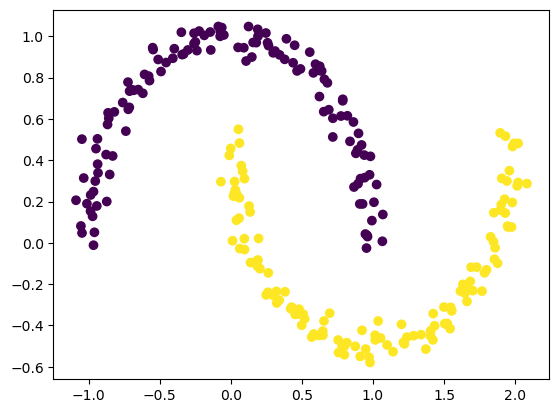

In [9]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
#scaling data 

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

In [14]:
x_scaled[0:10]

array([[-0.46849676,  1.39176756],
       [ 1.07723279, -1.30803742],
       [-1.77982836, -0.40694278],
       [ 1.55787215, -0.21048626],
       [-0.41730251, -0.20297688],
       [-0.65985969,  1.54934443],
       [-1.56284399,  0.70695852],
       [ 0.1443807 ,  0.91758723],
       [ 1.55502902, -0.49208394],
       [ 0.11242777,  1.23222501]])

In [15]:
#implementing DBSCAN algo

In [16]:
dbscan=DBSCAN(eps=0.3)
dbscan.fit(x_scaled)

,eps,0.3
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [17]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1])

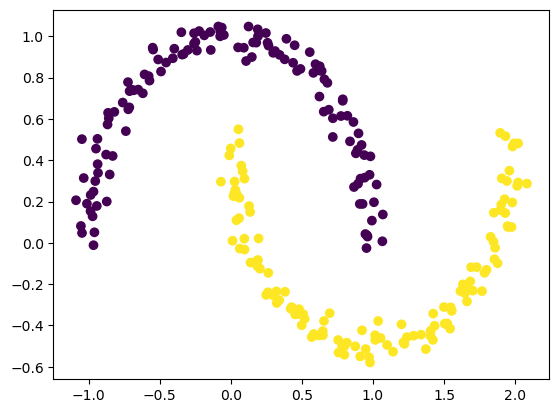

In [20]:
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)

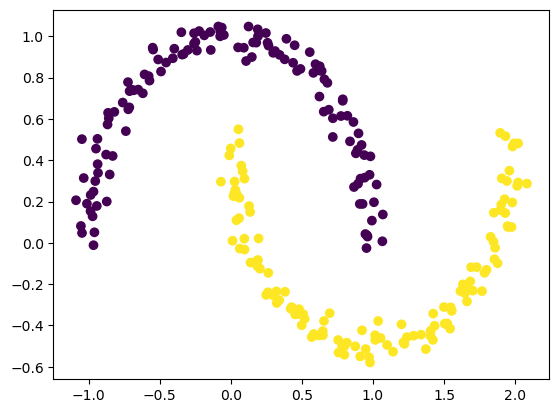

In [21]:
plt.scatter(X[:,0],X[:,1],c=y)

In [22]:
#Determinig epsilon (eps)

In [24]:
from sklearn.neighbors import NearestNeighbors
min_sample=3 # choosing 3 as there are 2 features, min_pts>=num_features + 1

In [25]:
neighbors=NearestNeighbors(n_neighbors=3)
neighbors_fit=neighbors.fit(x_scaled)

In [27]:
distance, indices=neighbors_fit.kneighbors(x_scaled)

In [36]:
distance=np.sort(distance[:,-1])
#sorting to get the last (3rd) distance

Text(0, 0.5, '3rd Nearest Neighbor')

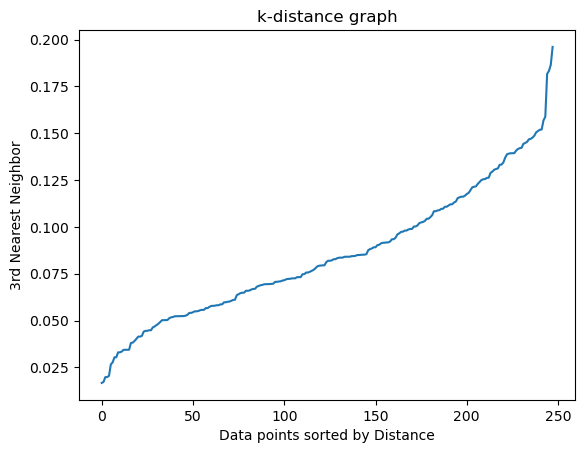

In [37]:
plt.plot(distance)
plt.title('k-distance graph')
plt.xlabel('Data points sorted by Distance')
plt.ylabel('3rd Nearest Neighbor')

In [ ]:
# eps would be between 0.125 and 0.150

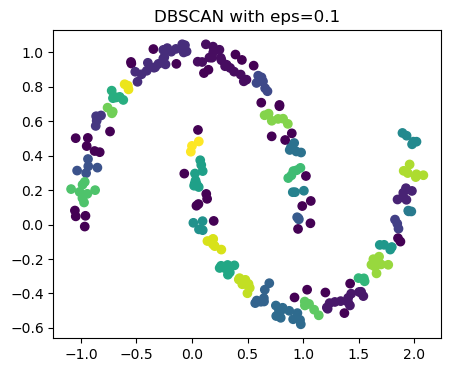

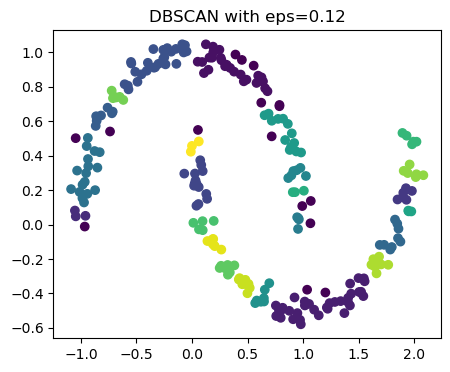

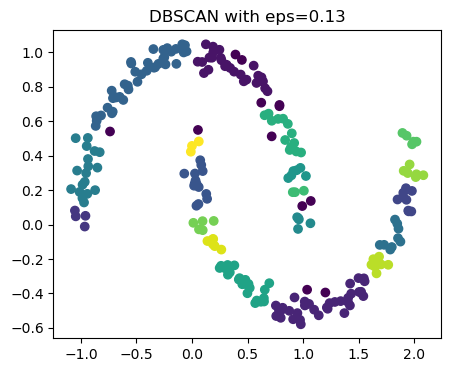

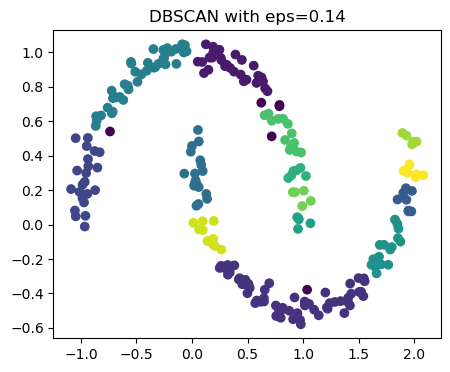

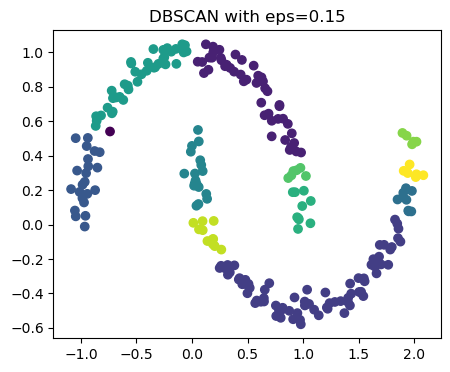

In [39]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

for eps in [0.10, 0.12, 0.13, 0.14, 0.15]:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(x_scaled)
    
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.title(f"DBSCAN with eps={eps}")
    plt.show()